## Batch Parameters and Aggregation
This notebook lets you set parameters, call an R script called consumption_rate.R for one or more CSVs, and aggregate results into a long-format summary where each row is a channel with `uL_mg_hr`, `temp_C`, and metadata.

## Configuration

Set paths and default parameters.

In [2]:
import pandas as pd
import subprocess
from pathlib import Path

# Paths
#First analyses sent by Adriana

#Next csv and R scripts sent by Adriana December 1
#DATA_DIR = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/adriana_final_r')
#Next csv and R scripts sent by Adriana January 14
DATA_DIR = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/csvs-and-code-jan2026')
OUT_DIR = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/processed')
R_SCRIPT = Path('/Users/oakley/Documents/GitHub/signal_respirometry/scripts/consumption_rate.R')

# Create output directory if needed
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Mass adjustment options: Control whether to use corrected masses separately for RMR and M
# Corrected mass = mass * (individuals / recovered_individuals) when recovered_individuals is specified
corrected_mass_RMR = True   # Use corrected mass for RMR output
corrected_mass_M = True     # Use corrected mass for M formula

# Default parameters
DEFAULT_SAL = 33
DEFAULT_CONTROL = 'Ch1'
DEFAULT_CHANNELS = ['Ch2', 'Ch3', 'Ch4']
DEFAULT_MASSES = [0.00024, 0.00024, 0.00024]  # grams
DEFAULT_VOL_CONTROL = 0.002  # liters
DEFAULT_VOLUMES = [0.002, 0.002, 0.002]  # liters
DEFAULT_START_HOUR = 1
DEFAULT_END_HOUR = 8
DEFAULT_MICROBIAL_CUTOFF = 5

## Define Trials

Each "run" is a dictionary with trial-specific parameters and meta-data.

### Trial 1 (10 Nov 2025) - Night
- Box2: small vessels (2ml), 1 animal each
- Box3: cylinders (260-268ml), 20 animals each
- Newbox: small vessels (2ml), 1 animal each - using newpyro CSV format

In [3]:
# Define runs here and in subsequent cells
# Each run can override defaults or use them

trial1_runs = [
    {
        'trial': 'trial1',
        'brick': 'box2',
        'csv': DATA_DIR / 'box2-trial1.csv',
        'individuals': [1,1,1],
        'masses': [0.0002263, 0.0002099, 0.0002703],  # measured (1 animal per channel)
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '10Nov2025',
            'environment': 'night'
        }
    },

    {
        'trial': 'trial1',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial1.csv',
        'individuals': [20,20,20],
        #'recovered_individuals': [21,18,15], #technically recovered 21, but setting to 20 assuming we didn't reallly ever add one
        'recovered_individuals': [21,18,15],
        'masses': [0.0076, 0.0065, 0.0055], #measured mass values of recovered animals
        #Subtract 2 ml for each cylinder because we had a stir bar in each
        #'volumes': [0.264, 0.262, 0.260],  # cylinders in ml → L
        'volumes': [0.262, 0.260, 0.258],
        'vol_control': 0.266,  # Ch1 control cylinder
        'metadata': {
            'vessel': 'cylinder',
            'date': '10Nov2025',
            'environment': 'night'
        }
    },
    {
        'trial': 'trial1',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial1.csv',
        'individuals': [1,1,1],
        'masses': [0.0002513, 0.000297, 0.0001811],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '10Nov2025',
            'environment': 'night'
        }
    },
]

### Trial 2 (11 Nov 2025) - Night
**Note:** Box2 and Box3 had crashes.
Only Data then is from Newbox: medium vessels (25ml), 5 animals each


In [4]:
trial2_runs = [
    {
        'trial': 'trial2',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial2.csv',  # Using newpyro CSV format
        'individuals': [5,5,5],
        'recovered_individuals': [5,4,5],
        'masses': [0.0011, 0.0009, 0.0011],  # 5 animals × 0.00024 = 0.0012 g
        'volumes': [0.025, 0.025, 0.025],  # 25 ml each
        'vol_control': 0.025,
        'metadata': {
            'vessel': 'medium',
            'date': '11Nov2025',
            'environment': 'night'
        }
    },
]

### Trial 3 (12 Nov 2025) - Night
- Box2: cylinders (260, 262, 264, 268 ml), 20 animals each
- Box3: medium vessels (25ml), 5 animals each
- Newbox: small vessels (2ml), 1 animal each

In [5]:
trial3_runs = [
    {
        'trial': 'trial3',
        'brick': 'box2',
        'csv': DATA_DIR / 'box2-trial3.csv',
        'individuals': [20,20,20],
        'recovered_individuals': [20,20,17],
        #'masses': [0.0049, 0.0047, 0.005058824],  these are corrected masses
        'masses': [0.0049, 0.0047, 0.0043],
        'volumes': [0.262, 0.264, 0.268],  # cylinders Ch2, Ch3, Ch4 in L
        'vol_control': 0.260,  # Ch1 control cylinder

        'metadata': {
            'vessel': 'cylinder',
            'date': '12Nov2025',
            'environment': 'night',
            'notes': 'Ch2 closest to GoPro, Ch4 farthest from GoPro'
        }
    },
    {
        'trial': 'trial3',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial3.csv',
        'individuals': [5,5,5],
        'recovered_individuals': [5,5,4],
        'masses': [0.0011, 0.001, 0.0009],  # 5 animals × 0.00024 = 0.0012 g
        'volumes': [0.025, 0.025, 0.025],  # 25 ml each
        'vol_control': 0.025,
        'metadata': {
            'vessel': 'medium',
            'date': '12Nov2025',
            'environment': 'night'
        }
    },
    {
        'trial': 'trial3',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial3.csv',  # Using newpyro CSV format
        'masses': [0.0002168, 0.0001989, 0.0002552],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'microbial_cutoff_hour': 4,  # match the cutoff hour used in R script
        'metadata': {
            'vessel': 'small',
            'date': '12Nov2025',
            'environment': 'night'
        }
    },
]

#### Notes for discussion Trial 3 cylinders do not match XL spreadsheet. I don't understand "mass adjusted" either

- For box2, and box3 it does match
- but what is "mass adjusted" and should that be used instead?

- newbox is cylinders do not match but are also very low (perhaps cylinder order is different).
- In addition, Adriana reports a broken cylinder which is not represented here



### Trial 4 (13 Nov 2025) - Night
- Box2: small vessels (2ml), 1 animal each
- Box3: small vessels (2ml), 1 animal each
- Newbox: cylinders (260, 262, 264, 268 ml), 20 animals each (start_hour=3)

In [6]:
trial4_runs = [
    {
        'trial': 'trial4',
        'brick': 'box2',
        'csv': DATA_DIR / 'box2-trial4.csv',
        'masses': [0.0002187, 0.0003741, 0.0002074],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '13Nov2025',
            'environment': 'night'
        }
    },
    {
        'trial': 'trial4',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial4.csv',
        'masses': [0.0002946, 0.0002209, 0.0002518],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '13Nov2025',
            'environment': 'night'
        }
    },
    {
        'trial': 'trial4',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial4.csv',
        'individuals': [20, 20],  # Ch2, Ch4 only (Ch3 animals were lost before weighing)
        'channels': ['Ch2', 'Ch4'],
        'recovered_individuals': [17, 20],  # Note Ch3 animals were lost before weighing
        'masses': [0.0045, 0.0049],  # 20 animals per cylinder
        'volumes': [0.262, 0.268],  # cylinders Ch2, Ch4 (from R script: vol02=0.262, vol04=0.268)
        'vol_control': 0.26,  # Ch1 control cylinder (from R script: volmicr=0.26)
        'metadata': {
            'vessel': 'cylinder',
            'date': '13Nov2025',
            'environment': 'night'
        }
    },
]

### Trial 4.5 (14 Nov 2025) - Day (Same animals as Trial 4), using only small vials not cylinders

In [7]:
trial4_5_runs = [
    {
        'trial': 'trial4.5',
        'brick': 'box2',
        'csv': DATA_DIR / 'box2-trial4-light.csv',
        'masses': [0.0002187, 0.0003741, 0.0002074],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '14Nov2025',
            'environment': 'day',
            'notes': 'Same animals as trial4'
        }
    },
    {
        'trial': 'trial4.5',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial4-light.csv',
        'channels': ['Ch3', 'Ch4'],          # override defaults (no Ch2 in this file)
        'masses': [0.0002209, 0.0002518],  # 1 animal per channel
        'volumes': [0.002, 0.002],    # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '14Nov2025',
            'environment': 'day',
            'notes': 'Same animals as trial4'
        }
    },
]

### Trial 5 (14 Nov 2025) - Night Environment

In [8]:
trial5_runs = [
    {
        'trial': 'trial5',
        'brick': 'box2',
        'csv': DATA_DIR / 'box2-trial5.csv',
        'individuals': [20,20,20],
        'recovered_individuals': [15, 15, 15],  # Only 2 cylinders, one broke
        'channels': ['Ch2','Ch4'],  # Only 3 channels one cylinder broke
        'masses': [0.0033, 0.0036],  
        'volumes': [0.262, 0.268],  
        'vol_control': 0.260, 
        'metadata': {
            'vessel': 'cylinder',
            'date': '14Nov2025',
            'environment': 'night',
            'notes': 'One cylinder broke, only 3 channels available'
        }
    },
    {
        'trial': 'trial5',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial5.csv',
        'masses': [0.0001893, 0.0003351, 0.0003627],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '14Nov2025',
            'environment': 'night'
        }
    },
    {
        'trial': 'trial5',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial5.csv',
        'masses': [0.0002234, 0.0002704, 0.0002277],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '14Nov2025',
            'environment': 'night'
        }
    },
]

### Trial 5.5 (15 Nov 2025) - Day Environment (Same animals as Trial 5)

In [9]:
trial5_5_runs = [
    {
        'trial': 'trial5.5',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial5-light.csv',
        'masses': [0.0002234, 0.0002704, 0.0002277],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '15Nov2025',
            'environment': 'day',
            'notes': 'Same animals as trial5'
        }
    },
    {
        'trial': 'trial5.5',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial5-light.csv',
        'channels': ['Ch2', 'Ch3', 'Ch4'],  # measurement channels (control from separate CSV)
        'control': 'Ch1',
        'control_csv': DATA_DIR / 'newpyro-trial5-light.csv',
        'masses': [0.0001893, 0.0003351, 0.0003627],  # Same animals as trial5
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '15Nov2025',
            'environment': 'day',
            'notes': 'Control from newpyro-trial5-light.csv'
        }
    },
]

### Trial 6 (16 Nov 2025) - Day 
**Note:** Ch1 serves as control for both box3 and newbox

In [10]:
trial6_runs = [
    {
        'trial': 'trial6',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial6-light.csv',
        'channels': ['Ch2', 'Ch3', 'Ch4'],  # Ch1 missing, get from control_csv
        'control': 'Ch1',
        'control_csv': DATA_DIR / 'newpyro-trial6-light.csv',
        'masses': [0.0002401, 0.0002579, 0.0002079],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '16Nov2025',
            'environment': 'day',
            'notes': 'Ch1 control from newpyro-trial6-light.csv'
        }
    },

    {
        'trial': 'trial6',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial6-light.csv',
        'control': 'Ch1',
        'masses': [0.000193, 0.0002411, 0.0002281],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '16Nov2025',
            'environment': 'day',
            'notes': 'Ch1 control in same CSV'
        }
    },
]

### Trial 6.5 (16 Nov 2025) - Night Environment (Same animals as Trial 6)

In [11]:
trial6_5_runs = [
    {
        'trial': 'trial6.5',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial6-dark.csv',
        'channels': ['Ch2', 'Ch4'],  # only Ch2 and Ch4 in this CSV (Ch3 missing)
        'control': 'Ch1',
        'control_csv': DATA_DIR / 'newpyro-trial6-dark.csv',  # get control from newbox CSV
        'masses': [0.0002401, 0.0002079],  # only 2 masses for Ch2 and Ch4
        'volumes': [0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '16Nov2025',
            'environment': 'night',
            'notes': 'Ch1 control from newpyro-trial6-dark.csv; Ch3 missing from box3 CSV'
        }
    },
    {
        'trial': 'trial6.5',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial6-dark.csv',
        'control': 'Ch1',  # Ch1 is in the same CSV
        'masses': [0.000193, 0.0002411, 0.0002281],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '16Nov2025',
            'environment': 'night',
            'notes': 'Same animals as trial6; Ch1 control in same CSV'
        }
    },
]

### Trial 7 (17 Nov 2025) - Day Environment

In [12]:
trial7_runs = [
    {
        'trial': 'trial7',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial7-light.csv',
        'control': 'Ch1',
        'masses': [0.0002279, 0.0002633, 0.0002362],  # measured masses (N2, N3, N4)
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '17Nov2025',
            'environment': 'day',
            'notes': 'Ch1 control in same CSV'
        }
    },
    {
        'trial': 'trial7',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial7-light.csv',
        'channels': ['Ch2', 'Ch3', 'Ch4'],  # Ch1 missing, get from control_csv
        'control': 'Ch1',
        'control_csv': DATA_DIR / 'newpyro-trial7-light.csv',
        'masses': [0.0002644, 0.0002535, 0.000249],  # measured masses (B3C2, B3C3, B3C4)
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '17Nov2025',
            'environment': 'day',
            'notes': 'Ch1 control from newpyro-trial7-light.csv'
        }
    },
]

### Trial 7.5 (17 Nov 2025) - Night Environment (Same animals as Trial 7)

In [13]:
trial7_5_runs = [
    {
        'trial': 'trial7.5',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial7-dark.csv',
        'control': 'Ch1',
        'masses': [0.0002279, 0.0002633, 0.0002362],  # measured masses (N2, N3, N4) - same animals as trial7
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '17Nov2025',
            'environment': 'night',
            'notes': 'Same animals as trial7; Ch1 control in same CSV'
        }
    },
    {
        'trial': 'trial7.5',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial7-dark.csv',
        'channels': ['Ch2', 'Ch3', 'Ch4'],  # Ch1 missing, get from control_csv
        'control': 'Ch1',
        'control_csv': DATA_DIR / 'newpyro-trial7-dark.csv',
        'masses': [0.0002644, 0.0002535, 0.000249],  # measured masses (B3C2, B3C3, B3C4) - same animals as trial7
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '17Nov2025',
            'environment': 'night',
            'notes': 'Same animals as trial7; Ch1 control from newpyro-trial7-dark.csv'
        }
    },
]

### Combine All Trials
This cell aggregates all trial run definitions from above into a single `runs` list.

In [14]:
# Combine all trial runs into a single list
runs = (
    trial1_runs + 
    trial2_runs + 
    trial3_runs + 
    trial4_runs + 
    trial4_5_runs + 
    trial5_runs + 
    trial5_5_runs + 
    trial6_runs + 
    trial6_5_runs + 
    trial7_runs + 
    trial7_5_runs
)

print(f"Total runs: {len(runs)}")
print(f"\nRuns by trial:")
for trial in sorted(set(r['trial'] for r in runs)):
    count = len([r for r in runs if r['trial'] == trial])
    print(f"  {trial}: {count} run(s)")

Total runs: 25

Runs by trial:
  trial1: 3 run(s)
  trial2: 1 run(s)
  trial3: 3 run(s)
  trial4: 3 run(s)
  trial4.5: 2 run(s)
  trial5: 3 run(s)
  trial5.5: 2 run(s)
  trial6: 2 run(s)
  trial6.5: 2 run(s)
  trial7: 2 run(s)
  trial7.5: 2 run(s)


## Functions
Define functions to call the R script for individual runs.

In [15]:
def run_respirometry_analysis(run, defaults=None):
    """
    Call consumption_rate.R for a single run.
    
    Args:
        run: dict with 'csv', 'trial', 'brick', and optional parameters
        defaults: dict with default values for missing parameters
    
    Returns:
        tuple: (success: bool, message: str)
    """
    global corrected_mass_RMR
    
    if defaults is None:
        defaults = {}
    
    csv_path = run['csv']
    if not csv_path.exists():
        return False, f"CSV not found: {csv_path}"
    
    
    
    # Build R script arguments
    args = [
        'Rscript', '--vanilla', str(R_SCRIPT),
        '--csv', str(csv_path),
        '--sal', str(run.get('sal', defaults.get('sal', DEFAULT_SAL))),
        '--control', run.get('control', defaults.get('control', DEFAULT_CONTROL)),
        '--channels', ','.join(run.get('channels', defaults.get('channels', DEFAULT_CHANNELS))),
    ]
    
    # If a separate control CSV is provided, pass it along (support both keys)
    control_csv = run.get('control_csv', run.get('control-csv', None))
    if control_csv is not None:
        args += ['--control_csv', str(control_csv)]
    
    # Calculate masses to pass to R script
    # If corrected_mass_RMR=True and recovered_individuals specified, calculate original inferred masses
    masses_g = run.get('masses', defaults.get('masses', DEFAULT_MASSES))
    individuals = run.get('individuals', None)
    recovered_individuals = run.get('recovered_individuals', None)
    
    if corrected_mass_RMR and individuals is not None and recovered_individuals is not None:
        # Calculate original/inferred masses: corrected_mass * (individuals / recovered_individuals)
        original_masses = [m * (indiv / recov) for m, indiv, recov in zip(masses_g, individuals, recovered_individuals)]
        masses_to_pass = original_masses
    else:
        masses_to_pass = masses_g
    
    args += ['--masses', ','.join(str(m) for m in masses_to_pass)]
    
    args += [
        '--vol_control', str(run.get('vol_control', defaults.get('vol_control', DEFAULT_VOL_CONTROL))),
        '--volumes', ','.join(str(v) for v in run.get('volumes', defaults.get('volumes', DEFAULT_VOLUMES))),
        '--start_hour', str(run.get('start_hour', defaults.get('start_hour', DEFAULT_START_HOUR))),
        '--end_hour', str(run.get('end_hour', defaults.get('end_hour', DEFAULT_END_HOUR))),
        '--microbial_cutoff_hour', str(run.get('microbial_cutoff_hour', defaults.get('microbial_cutoff_hour', DEFAULT_MICROBIAL_CUTOFF))),
        '--out', str(OUT_DIR),
    ]
    
    # Add optional flags if specified
    if run.get('mask_channels', False):
        args += ['--mask_channels', 'true']
    if 'cutoff_inclusive' in run:
        args += ['--cutoff_inclusive', 'true' if run['cutoff_inclusive'] else 'false']
    if run.get('debug', False):
        args += ['--debug', 'true']
    if 'ignore' in run:
        args += ['--ignore', run['ignore']]
    
    # Run R script
    try:
        result = subprocess.run(
            args,
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )
        return True, f"Success: {run['trial']}-{run['brick']}"
    except subprocess.CalledProcessError as e:
        error_msg = f"Failed: {run['trial']}-{run['brick']}\n"
        if e.stderr:
            error_msg += f"Error: {e.stderr}"
        return False, error_msg

## Run Analysis of Single Trial (Mainly for Troubleshooting)

In [16]:
# --- Run and view a single trial (all bricks) ---
# Select all runs for a specific trial
trial_name = 'trial7.5'
trial_runs_to_check = [r for r in runs if r['trial'] == trial_name]

# Mass adjustment parameters (same as in batch aggregation)
ave_mass = 0.000249             # average mass in grams (= 0.249 mg)
scaling_coefficient = -0.25     # scaling exponent for mass adjustment

all_rows = []

for single_run in trial_runs_to_check:
    success, message = run_respirometry_analysis(single_run)
    print(message)
    
    # Load and display the summary for this run
    csv_name = single_run['csv'].name
    summary_path = OUT_DIR / f"{csv_name}_R_summary.csv"
    
    if not summary_path.exists():
        print(f"  Warning: Summary not found for {single_run['brick']}")
        continue
    
    r_df = pd.read_csv(summary_path)
    
    # Get channels and masses from run config
    channels = single_run.get('channels', DEFAULT_CHANNELS)
    masses_g = single_run.get('masses', DEFAULT_MASSES)
    
    # Reshape: gather all *_uL_mg_hr columns into rows
    channel_cols = [col for col in r_df.columns if col.endswith('_uL_mg_hr')]
    
    for col in channel_cols:
        channel = col.replace('_uL_mg_hr', '')
        uL_mg_hr_value = r_df[col].iloc[0]
        
        # Calculate mass-adjusted M (uL_hr) using per-individual channel mass
        try:
            ch_idx = channels.index(channel)
            channel_mass_g = masses_g[ch_idx]
            channel_mass_mg = channel_mass_g * 1000
            
            # Get number of individuals for this channel and calculate corrected mass
            individuals = single_run.get('individuals', None)
            recovered_individuals = single_run.get('recovered_individuals', None)
            
            # corrected_mass_mg (total channel mass) = (what_we_weighed / recovered) * intended_individuals
            corrected_mass_mg = None
            if individuals is not None and recovered_individuals is not None:
                num_individuals = individuals[ch_idx]
                num_recovered = recovered_individuals[ch_idx]
                corrected_mass_mg = (channel_mass_mg / num_recovered) * num_individuals
            
            if individuals is not None:
                num_individuals = individuals[ch_idx]
                # Calculate mass for RMR output (may use corrected or uncorrected)
                if corrected_mass_RMR and recovered_individuals is not None:
                    num_recovered = recovered_individuals[ch_idx]
                    mass_for_rmr_mg = corrected_mass_mg / num_individuals if corrected_mass_mg is not None else channel_mass_mg / num_individuals
                else:
                    mass_for_rmr_mg = channel_mass_mg / num_individuals
                
                # Calculate mass for M formula (may use corrected or uncorrected)
                if corrected_mass_M and recovered_individuals is not None:
                    # Use corrected mass divided by total intended individuals
                    mass_for_m_mg = corrected_mass_mg / num_individuals if corrected_mass_mg is not None else channel_mass_mg / num_individuals
                else:
                    # Use uncorrected mass divided by recovered individuals (actual animals present)
                    if recovered_individuals is not None:
                        num_recovered = recovered_individuals[ch_idx]
                        mass_for_m_mg = channel_mass_mg / num_recovered
                    else:
                        mass_for_m_mg = channel_mass_mg / num_individuals
            else:
                num_individuals = None
                mass_for_rmr_mg = channel_mass_mg
                mass_for_m_mg = channel_mass_mg
            
            ave_mass_mg = ave_mass * 1000
            uL_hr_value = (uL_mg_hr_value / (mass_for_m_mg ** scaling_coefficient)) * (ave_mass_mg ** scaling_coefficient)
        except (ValueError, IndexError):
            num_individuals = None
            mass_for_rmr_mg = None
            mass_for_m_mg = None
            corrected_mass_mg = None
            uL_hr_value = None
        
        row = {
            'brick': single_run.get('brick', None),
            'channel': channel,
            'n': num_individuals,
            'total_mass_mg': channel_mass_mg,
            'corrected_mass_mg': corrected_mass_mg,
            'RMR': uL_mg_hr_value,
            'M': uL_hr_value,
            'temp_C': r_df['temp_C'].iloc[0] if 'temp_C' in r_df.columns else None,
            'vessel': single_run.get('metadata', {}).get('vessel', None),
            'environment': single_run.get('metadata', {}).get('environment', None)
        }
        all_rows.append(row)

# Display combined results for entire trial
if all_rows:
    results_df = pd.DataFrame(all_rows)
    print(f"\n{'='*60}")
    print(f"Results for {trial_name} (all bricks):")
    display(results_df)
    print(f"{'='*60}")

else:    print(f"No results collected for {trial_name}")

Success: trial7.5-newbox
Success: trial7.5-box3

Results for trial7.5 (all bricks):


,brick,channel,n,total_mass_mg,corrected_mass_mg,RMR,M,temp_C,vessel,environment
0,newbox,Ch2,None,0.2279,None,3.967867,3.880997,26.549,small,night
1,newbox,Ch3,None,0.2633,None,2.798130,2.837467,26.549,small,night
2,newbox,Ch4,None,0.2362,None,2.626962,2.592531,26.549,small,night
3,box3,Ch2,None,0.2644,None,1.358387,1.378920,26.417,small,night
4,box3,Ch3,None,0.2535,None,1.360360,1.366465,26.417,small,night
5,box3,Ch4,None,0.2490,None,1.414543,1.414543,26.417,small,night


## Run Batch Data Analyses

In [16]:
# Process all runs
results = []

for run in runs:
    run_id = f"{run['trial']}-{run['brick']}"
    print(f"Processing {run_id}...")
    success, message = run_respirometry_analysis(run)
    results.append({
        'trial': run['trial'],
        'brick': run['brick'],
        'success': success,
        'message': message
    })
    if not success:
        print(f"  ❌ {message}")
    else:
        print(f"  ✓ {message}")

# Summary
results_df = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"Completed: {results_df['success'].sum()}/{len(results_df)} runs succeeded")
print(f"{'='*60}")
display(results_df)


Processing trial1-box2...
  ✓ Success: trial1-box2
Processing trial1-box3...
  ✓ Success: trial1-box3
Processing trial1-newbox...
  ✓ Success: trial1-newbox
Processing trial2-newbox...
  ✓ Success: trial2-newbox
Processing trial3-box2...
  ✓ Success: trial3-box2
Processing trial3-box3...
  ✓ Success: trial3-box3
Processing trial3-newbox...
  ✓ Success: trial3-newbox
Processing trial4-box2...
  ✓ Success: trial4-box2
Processing trial4-box3...
  ✓ Success: trial4-box3
Processing trial4-newbox...
  ✓ Success: trial4-newbox
Processing trial4.5-box2...
  ✓ Success: trial4.5-box2
Processing trial4.5-box3...
  ✓ Success: trial4.5-box3
Processing trial5-box2...
  ✓ Success: trial5-box2
Processing trial5-box3...
  ✓ Success: trial5-box3
Processing trial5-newbox...
  ✓ Success: trial5-newbox
Processing trial5.5-newbox...
  ✓ Success: trial5.5-newbox
Processing trial5.5-box3...
  ✓ Success: trial5.5-box3
Processing trial6-box3...
  ✓ Success: trial6-box3
Processing trial6-newbox...
  ✓ Success: t

,trial,brick,success,message
0,trial1,box2,True,Success: trial1-box2
1,trial1,box3,True,Success: trial1-box3
2,trial1,newbox,True,Success: trial1-newbox
3,trial2,newbox,True,Success: trial2-newbox
4,trial3,box2,True,Success: trial3-box2
5,trial3,box3,True,Success: trial3-box3
6,trial3,newbox,True,Success: trial3-newbox
7,trial4,box2,True,Success: trial4-box2
8,trial4,box3,True,Success: trial4-box3
9,trial4,newbox,True,Success: trial4-newbox


### Create dataframe for all trials

In [17]:
import pandas as pd

# ============================================================================
# MASS ADJUSTMENT PARAMETERS
# ============================================================================
ave_mass = 0.000249             # average mass in grams (= 0.249 mg)
scaling_coefficient = -0.25     # scaling exponent for mass adjustment
# Formula: uL_hr = (uL_mg_hr / (mass_mg ^ scaling_coefficient)) * (ave_mass_mg ^ scaling_coefficient)
# Note: masses are converted from grams (g) to milligrams (mg) for calculation
# ============================================================================

# Collect all R summary CSVs
summary_rows = []

for run in runs:
    csv_name = run['csv'].name
    summary_path = OUT_DIR / f"{csv_name}_R_summary.csv"
    
    run_id = f"{run['trial']}-{run['brick']}"
    if not summary_path.exists():
        print(f"Warning: Summary not found for {run_id}")
        continue
    
    # Read R summary
    r_df = pd.read_csv(summary_path)
    
    # Get channels from run config
    channels = run.get('channels', DEFAULT_CHANNELS)
    # Get masses from run config (in grams)
    masses_g = run.get('masses', DEFAULT_MASSES)
    
    # Extract per-channel results
    for ch_idx, ch in enumerate(channels):
        col = f'{ch}_uL_mg_hr'
        if col in r_df.columns:
            uL_mg_hr_value = float(r_df[col].iloc[0])
            # Get the mass for this specific channel (in grams) and convert to mg
            channel_mass_g = masses_g[ch_idx]
            channel_mass_mg = channel_mass_g * 1000
            
            # Get number of individuals for this channel and calculate corrected mass
            individuals = run.get('individuals', None)
            recovered_individuals = run.get('recovered_individuals', None)
            
            # corrected_mass_mg (total channel mass) = (what_we_weighed / recovered) * intended_individuals
            corrected_mass_mg = None
            if individuals is not None and recovered_individuals is not None:
                num_individuals = individuals[ch_idx]
                num_recovered = recovered_individuals[ch_idx]
                corrected_mass_mg = (channel_mass_mg / num_recovered) * num_individuals
            
            if individuals is not None:
                num_individuals = individuals[ch_idx]
                # Calculate mass for RMR output (may use corrected or uncorrected)
                if corrected_mass_RMR and recovered_individuals is not None:
                    mass_for_rmr_mg = corrected_mass_mg / num_individuals if corrected_mass_mg is not None else channel_mass_mg / num_individuals
                else:
                    mass_for_rmr_mg = channel_mass_mg / num_individuals
                
                # Calculate mass for M formula (may use corrected or uncorrected)
                if corrected_mass_M and recovered_individuals is not None:
                    # Use corrected mass divided by total intended individuals
                    mass_for_m_mg = corrected_mass_mg / num_individuals if corrected_mass_mg is not None else channel_mass_mg / num_individuals
                else:
                    # Use uncorrected mass divided by recovered individuals (actual animals present)
                    if recovered_individuals is not None:
                        num_recovered = recovered_individuals[ch_idx]
                        mass_for_m_mg = channel_mass_mg / num_recovered
                    else:
                        mass_for_m_mg = channel_mass_mg / num_individuals
            else:
                num_individuals = None
                mass_for_rmr_mg = channel_mass_mg
                mass_for_m_mg = channel_mass_mg
            
            # Calculate mass-adjusted M (uL_hr)
            ave_mass_mg = ave_mass * 1000
            uL_hr_value = (uL_mg_hr_value / (mass_for_m_mg ** scaling_coefficient)) * (ave_mass_mg ** scaling_coefficient)
            
            row = {
                'trial': run['trial'],
                'brick': run['brick'],
                'channel': ch,
                'n': num_individuals,
                'total_mass_mg': channel_mass_mg,
                'corrected_mass_mg': corrected_mass_mg,
                'RMR': uL_mg_hr_value,
                'M': uL_hr_value,
                'temp_C': float(r_df['temp_C'].iloc[0]) if 'temp_C' in r_df.columns else None,
            }
            # Add metadata if present
            if 'metadata' in run:
                row.update(run['metadata'])
            summary_rows.append(row)

# Create aggregated dataframe
if summary_rows:
    agg_df = pd.DataFrame(summary_rows)
    
    # Calculate A: RMR / (mass_per_individual ^ scaling_coefficient)
    # Use corrected_mass_mg if available, otherwise total_mass_mg
    # Divide by n (treat None as 1) to get per-individual mass
    def calculate_A(row):
        # Get mass to use (prefer corrected_mass_mg if available)
        mass_mg = row['corrected_mass_mg'] if pd.notna(row['corrected_mass_mg']) else row['total_mass_mg']
        
        # Get number of individuals (treat None as 1)
        n = row['n'] if pd.notna(row['n']) and row['n'] is not None else 1
        
        # Calculate per-individual mass
        mass_per_individual = mass_mg / n
        
        # Calculate A = RMR / (mass_per_individual ^ scaling_coefficient)
        if pd.notna(row['RMR']) and mass_per_individual > 0:
            return row['RMR'] / (mass_per_individual ** scaling_coefficient)
        else:
            return None
    
    agg_df['A'] = agg_df.apply(calculate_A, axis=1)
    
    # Reorder columns to place A between RMR and M
    cols = list(agg_df.columns)
    if 'A' in cols and 'RMR' in cols and 'M' in cols:
        cols.remove('A')
        rmr_idx = cols.index('RMR')
        cols.insert(rmr_idx + 1, 'A')
        agg_df = agg_df[cols]
    
    # Add filtered flag: False for trials 4 and 4.5, True otherwise
    agg_df['filtered'] = ~agg_df['trial'].isin(['trial4', 'trial4.5'])
    
    # Save aggregated summary
    agg_path = OUT_DIR / 'batch_summary.csv'
    agg_df.to_csv(agg_path, index=False)
    
    print(f"Aggregated summary saved to: {agg_path}")
    print(f"Total rows: {len(agg_df)}")
    # display(agg_df)  # Uncomment to see full dataframe

else:
    print("No results to aggregate.")

Aggregated summary saved to: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv
Total rows: 71


In [18]:
# Display a formatted table (excluding the 'file' and 'notes' columns) for quick review
if 'agg_df' in locals() and not agg_df.empty:
    display_cols = [col for col in agg_df.columns if col not in ('file', 'notes')]
    display(agg_df[display_cols])
else:
    print("No data available for display.")

,trial,brick,channel,n,total_mass_mg,corrected_mass_mg,RMR,A,M,temp_C,vessel,date,environment,filtered
0,trial1,box2,Ch2,1.0,0.2263,NaN,2.708969,1.868423,2.644998,27.948,small,10Nov2025,night,True
1,trial1,box2,Ch3,1.0,0.2099,NaN,3.669335,2.483650,3.515933,27.948,small,10Nov2025,night,True
2,trial1,box2,Ch4,1.0,0.2703,NaN,2.927729,2.111020,2.988427,27.948,small,10Nov2025,night,True
3,trial1,box3,Ch2,20.0,7.6000,7.238095,8.546660,6.628954,9.384154,28.233,cylinder,10Nov2025,night,True
4,trial1,box3,Ch3,20.0,6.5000,7.222222,8.352764,6.475010,9.166227,28.233,cylinder,10Nov2025,night,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,trial7.5,newbox,Ch3,NaN,0.2633,NaN,2.798130,2.004383,2.837467,26.549,small,17Nov2025,night,True
67,trial7.5,newbox,Ch4,NaN,0.2362,NaN,2.626962,1.831360,2.592531,26.549,small,17Nov2025,night,True
68,trial7.5,box3,Ch2,NaN,0.2644,NaN,1.358387,0.974067,1.378920,26.417,small,17Nov2025,night,True
69,trial7.5,box3,Ch3,NaN,0.2535,NaN,1.360360,0.965269,1.366465,26.417,small,17Nov2025,night,True


## Create Main Plots and Statistics

In [19]:
#We probably should remove all of Trial 4 because our filter was broken and it seems to have led to 
#very high background respiration rates. This cell tests the hypothesis that Trial 4 RMR is lower than
# the other trials, which would be consistent with high background

# Trial 4 vs Others: RMR comparison within vessel types (accounting for vessel size)
import pandas as pd
from scipy import stats

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them
use_unfiltered = True  # Note: typically True here since we're comparing trial4 itself

if 'agg_df' in locals() and not agg_df.empty:
    df = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()

    vessel_types = sorted(df['vessel'].unique())
    print("Trial 4 RMR vs other trials (per vessel type):\n")

    summary_rows = []
    for v in vessel_types:
        t4 = df[(df['trial'] == 'trial4') & (df['vessel'] == v)]['RMR']
        others = df[(df['trial'] != 'trial4') & (df['vessel'] == v)]['RMR']

        if t4.empty or others.empty:
            print(f"{v.title()}: insufficient data (trial4 n={len(t4)}, others n={len(others)})")
            continue

        # Summary stats
        t4_mean, t4_median, t4_std = t4.mean(), t4.median(), t4.std(ddof=1)
        o_mean, o_median, o_std = others.mean(), others.median(), others.std(ddof=1)

        # Welch's t-test (robust to unequal variance)
        t_stat, p_t = stats.ttest_ind(t4, others, equal_var=False)

        # Mann-Whitney U (non-parametric)
        try:
            u_stat, p_u = stats.mannwhitneyu(t4, others, alternative='two-sided')
        except ValueError:
            u_stat, p_u = float('nan'), float('nan')

        summary_rows.append({
            'vessel': v,
            'trial4_n': len(t4), 'others_n': len(others),
            'trial4_mean': t4_mean, 'others_mean': o_mean,
            'trial4_median': t4_median, 'others_median': o_median,
            'trial4_std': t4_std, 'others_std': o_std,
            't_stat': t_stat, 'p_t': p_t,
            'u_stat': u_stat, 'p_u': p_u
        })

    if summary_rows:
        comp_df = pd.DataFrame(summary_rows)
        display(comp_df)

        # Quick conclusion per vessel: is trial4 lower?
        comp_df['trial4_lower_mean'] = comp_df['trial4_mean'] < comp_df['others_mean']
        print("\nIs trial4 lower (mean RMR) per vessel?")
        for _, r in comp_df.iterrows():
            print(f"  {r['vessel']}: {'Yes' if r['trial4_lower_mean'] else 'No'} (p_t={r['p_t']:.4f}, p_u={r['p_u']:.4f})")
    else:
        print("No vessel types with sufficient data for comparison.")
else:
    print("agg_df is missing or empty.")

Trial 4 RMR vs other trials (per vessel type):

Medium: insufficient data (trial4 n=0, others n=6)


,vessel,trial4_n,others_n,trial4_mean,others_mean,trial4_median,others_median,trial4_std,others_std,t_stat,p_t,u_stat,p_u
0,cylinder,2,8,0.027528,5.844194,0.027528,6.391660,0.184651,2.439238,-6.668738,0.000238,0.0,0.044444
1,small,6,49,1.086438,1.673014,1.051243,1.414543,0.283553,1.005395,-3.179780,0.003803,101.0,0.225557



Is trial4 lower (mean RMR) per vessel?
  cylinder: Yes (p_t=0.0002, p_u=0.0444)
  small: Yes (p_t=0.0038, p_u=0.2256)



Summary statistics by group:


count      mean       std       min       max
vessel   environment                                               
cylinder night            8  5.844194  2.439238  2.897411  8.546660
medium   night            6  3.614779  1.015635  2.521120  5.398751
small    day             18  1.181223  0.696188  0.375336  2.995435
         night           26  2.097811  1.084139  0.384284  4.356231

/var/folders/pg/rkmvtptx175d4dsj5fd6w4d40000gp/T/ipykernel_2278/2640674031.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=groups, patch_artist=True,


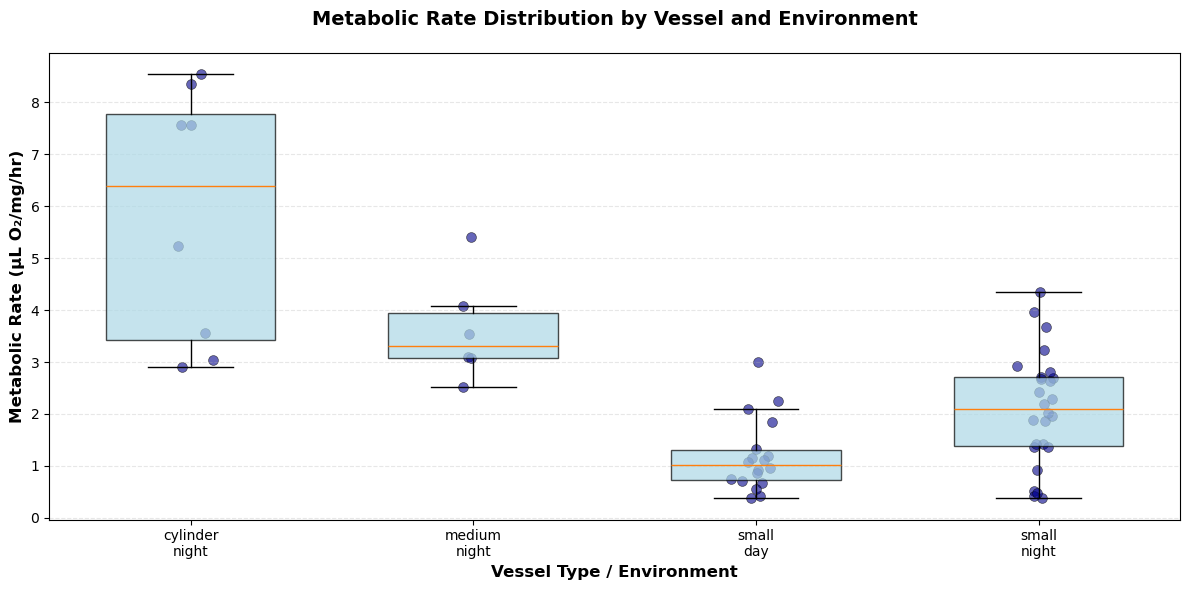

In [20]:
#This removes trials 4 and 4.5 from the plots and statistics because those trials used unfiltered water

import matplotlib.pyplot as plt
import numpy as np

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them
use_unfiltered = False

if 'agg_df' in locals() and not agg_df.empty:
    # Apply filtering based on toggle
    plot_df = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()
    # Group by vessel and environment if those columns exist
    group_cols = [col for col in ['vessel', 'environment'] if col in plot_df.columns]

    
    if group_cols:
        stats = plot_df.groupby(group_cols)['RMR'].agg(['count', 'mean', 'std', 'min', 'max'])
        print("\nSummary statistics by group:")
        display(stats)
        
        # Create box and whisker plot with individual data points
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Create a combined grouping column for x-axis
        plot_df['group'] = plot_df['vessel'] + '\n' + plot_df['environment']
        
        # Get unique groups and sort them
        groups = plot_df['group'].unique()
        groups = sorted(groups)
        
        # Prepare data for box plot
        data_by_group = [plot_df[plot_df['group'] == g]['RMR'].values for g in groups]
        
        # Create box plot
        bp = ax.boxplot(data_by_group, labels=groups, patch_artist=True,
                        widths=0.6, showfliers=False)
        
        # Style the boxes
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)
        
        # Overlay individual data points with jitter
        for i, group in enumerate(groups):
            y_data = plot_df[plot_df['group'] == group]['RMR'].values
            # Add jitter to x positions
            x_data = np.random.normal(i + 1, 0.04, size=len(y_data))
            ax.scatter(x_data, y_data, alpha=0.6, s=50, c='darkblue', edgecolors='black', linewidth=0.5)
        
        # Labels and formatting
        ax.set_ylabel('Metabolic Rate (µL O₂/mg/hr)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Vessel Type / Environment', fontsize=12, fontweight='bold')
        ax.set_title('Metabolic Rate Distribution by Vessel and Environment', fontsize=14, fontweight='bold', pad=20)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Rotate x-axis labels if needed
        plt.xticks(rotation=0, ha='center')
        
        plt.tight_layout()
        plt.show()
        
    else:
        print("\nOverall statistics:")
        print(plot_df['RMR'].describe())

else:    print("No data available for statistics.")

### Statistical Comparison: Day vs Night

Perform statistical tests to determine if metabolic rates differ significantly between day and night conditions.

In [21]:
from scipy import stats

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them
use_unfiltered = False

if 'agg_df' in locals() and not agg_df.empty:
    # Apply filtering based on toggle
    filtered_df = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()
    # Test for each vessel type separately
    vessel_types = filtered_df['vessel'].unique()
    
    print("Statistical Tests: Day vs Night Metabolic Rates")
    print("=" * 70)
    
    for vessel in vessel_types:
        vessel_data = filtered_df[filtered_df['vessel'] == vessel]
        day_data = vessel_data[vessel_data['environment'] == 'day']['RMR'].values
        night_data = vessel_data[vessel_data['environment'] == 'night']['RMR'].values
        
        if len(day_data) > 0 and len(night_data) > 0:
            # Perform t-test (assumes normality)
            t_stat, p_value_t = stats.ttest_ind(night_data, day_data)
            
            # Perform Mann-Whitney U test (non-parametric alternative)
            u_stat, p_value_u = stats.mannwhitneyu(night_data, day_data, alternative='two-sided')
            
            print(f"\n{vessel.upper()} VESSELS:")
            print(f"  Night: n={len(night_data)}, mean={night_data.mean():.2f}, std={night_data.std():.2f}")
            print(f"  Day:   n={len(day_data)}, mean={day_data.mean():.2f}, std={day_data.std():.2f}")
            print(f"  Difference: {night_data.mean() - day_data.mean():.2f} µL O₂/mg/hr")
            print(f"  % Change: {((day_data.mean() - night_data.mean()) / night_data.mean() * 100):.1f}%")
            print(f"\n  Independent t-test:")
            print(f"    t-statistic = {t_stat:.3f}, p-value = {p_value_t:.4f}")
            print(f"    {'SIGNIFICANT' if p_value_t < 0.05 else 'NOT significant'} at α=0.05")
            print(f"\n  Mann-Whitney U test (non-parametric):")
            print(f"    U-statistic = {u_stat:.1f}, p-value = {p_value_u:.4f}")
            print(f"    {'SIGNIFICANT' if p_value_u < 0.05 else 'NOT significant'} at α=0.05")
        else:
            print(f"\n{vessel.upper()} VESSELS:")
            print(f"  Insufficient data for comparison (day={len(day_data)}, night={len(night_data)})")
    
    print("\n" + "=" * 70)
else:
    print("No data available for statistical analysis.")

Statistical Tests: Day vs Night Metabolic Rates

SMALL VESSELS:
  Night: n=26, mean=2.10, std=1.06
  Day:   n=18, mean=1.18, std=0.68
  Difference: 0.92 µL O₂/mg/hr
  % Change: -43.7%

  Independent t-test:
    t-statistic = 3.158, p-value = 0.0029
    SIGNIFICANT at α=0.05

  Mann-Whitney U test (non-parametric):
    U-statistic = 355.0, p-value = 0.0040
    SIGNIFICANT at α=0.05

CYLINDER VESSELS:
  Insufficient data for comparison (day=0, night=8)

MEDIUM VESSELS:
  Insufficient data for comparison (day=0, night=6)



In [22]:
# Paired day vs night comparisons for matching brick+channel (trials x.0 vs x.5)
from scipy import stats

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them
use_unfiltered = False

if 'agg_df' in locals() and not agg_df.empty:
    # Apply filtering based on toggle
    analysis_df = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()
    
    pair_trials = [
        ('trial4', 'trial4.5'),
        ('trial5', 'trial5.5'),
        ('trial6', 'trial6.5'),
        ('trial7', 'trial7.5'),
    ]

    paired_rows = []
    for t_a, t_b in pair_trials:
        pair_df = analysis_df[analysis_df['trial'].isin([t_a, t_b])]
        if pair_df.empty:
            continue
        for (brick, channel), grp in pair_df.groupby(['brick', 'channel']):
            if len(grp) != 2:
                continue
            envs = set(grp['environment'])
            if envs != {'day', 'night'}:
                continue
            night_row = grp[grp['environment'] == 'night'].iloc[0]
            day_row = grp[grp['environment'] == 'day'].iloc[0]
            paired_rows.append({
                'pair': f'{t_a}_vs_{t_b}',
                'brick': brick,
                'channel': channel,
                'night_trial': night_row['trial'],
                'day_trial': day_row['trial'],
                'night': float(night_row['RMR']),
                'day': float(day_row['RMR']),
                'diff_night_minus_day': float(night_row['RMR'] - day_row['RMR']),
            })

    if paired_rows:
        paired_df = pd.DataFrame(paired_rows)
        display(paired_df)

        # Overall paired tests
        t_stat, p_t = stats.ttest_rel(paired_df['night'], paired_df['day'])
        w_stat, p_w = stats.wilcoxon(paired_df['night'], paired_df['day'], alternative='two-sided')

        print(f"\nOverall paired comparisons (all bricks/channels)")
        print(f"  n pairs = {len(paired_df)}")
        print(f"  mean night = {paired_df['night'].mean():.3f}, mean day = {paired_df['day'].mean():.3f}")
        print(f"  mean diff (night-day) = {paired_df['diff_night_minus_day'].mean():.3f}")
        print(f"  Paired t-test: t = {t_stat:.3f}, p = {p_t:.4f}")
        print(f"  Wilcoxon signed-rank: W = {w_stat:.1f}, p = {p_w:.4f}")

    else:
        print("No paired day/night matches found for the specified trial pairs.")
else:
    print("No data available (agg_df is missing or empty).")

,pair,brick,channel,night_trial,day_trial,night,day,diff_night_minus_day
0,trial5_vs_trial5.5,box3,Ch2,trial5,trial5.5,2.285837,2.245259,0.040578
1,trial5_vs_trial5.5,box3,Ch3,trial5,trial5.5,0.920854,0.427888,0.492965
2,trial5_vs_trial5.5,box3,Ch4,trial5,trial5.5,0.473624,0.706451,-0.232827
3,trial5_vs_trial5.5,newbox,Ch2,trial5,trial5.5,1.871534,0.756193,1.115341
4,trial5_vs_trial5.5,newbox,Ch3,trial5,trial5.5,1.876437,1.199553,0.676884
5,trial5_vs_trial5.5,newbox,Ch4,trial5,trial5.5,2.681803,2.995435,-0.313632
6,trial6_vs_trial6.5,box3,Ch2,trial6.5,trial6,1.954137,0.949858,1.004280
7,trial6_vs_trial6.5,box3,Ch4,trial6.5,trial6,2.182509,0.679472,1.503037
8,trial6_vs_trial6.5,newbox,Ch2,trial6.5,trial6,3.222056,1.841349,1.380707
9,trial6_vs_trial6.5,newbox,Ch3,trial6.5,trial6,1.424907,0.920279,0.504627



Overall paired comparisons (all bricks/channels)
  n pairs = 17
  mean night = 2.026, mean day = 1.229
  mean diff (night-day) = 0.797
  Paired t-test: t = 5.053, p = 0.0001
  Wilcoxon signed-rank: W = 5.0, p = 0.0002


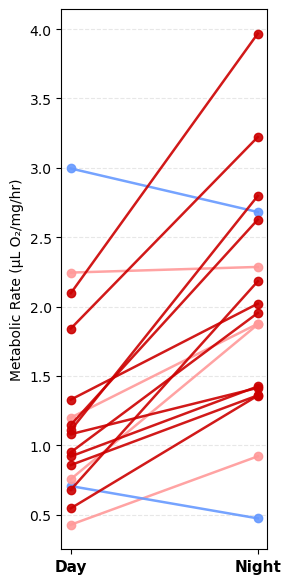

In [23]:
# Slopegraph: Day (left) vs Night (right) for paired comparisons
import matplotlib.pyplot as plt

if 'paired_rows' in locals() and paired_rows:
    plot_df = pd.DataFrame(paired_rows).copy()
    # Ensure order is consistent
    plot_df['label'] = plot_df['brick'] + ' | ' + plot_df['channel'] + ' | ' + plot_df['pair']
    plot_df = plot_df.sort_values(['pair', 'brick', 'channel'])
    
    # Define which trials started in day vs night
    started_in_day = {'trial4_vs_trial4.5', 'trial5_vs_trial5.5'}
    started_in_night = {'trial6_vs_trial6.5', 'trial7_vs_trial7.5'}

    fig, ax = plt.subplots(figsize=(3, max(4, 0.35 * len(plot_df))))
    x_day, x_night = 0, 1

    for _, row in plot_df.iterrows():
        y_day = row['day']
        y_night = row['night']
        pair = row['pair']
        
        # Determine color based on direction and which environment started first
        if y_night > y_day:  # Night higher than day (red)
            if pair in started_in_day:
                color = '#ff9999'  # Light red (started in day)
            else:
                color = '#cc0000'  # Dark red (started in night)
        else:  # Day higher or equal (blue)
            if pair in started_in_day:
                color = '#6699ff'  # Light blue (started in day)
            else:
                color = '#0044cc'  # Dark blue (started in night)
        
        ax.plot([x_day, x_night], [y_day, y_night], marker='o', color=color, linewidth=1.8, alpha=0.9)
        #ax.text(x_day - 0.02, y_day, f"{row['label']}", ha='right', va='center', fontsize=8)

    ax.set_xticks([x_day, x_night])
    ax.set_xticklabels(['Day', 'Night'], fontsize=11, fontweight='bold')
    ax.set_ylabel('Metabolic Rate (µL O₂/mg/hr)')
    #ax.set_title('Paired Day–Night Slopegraph (per brick/channel)', fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No paired data available to plot.")

### Plot activity compared to consumption

In [26]:
# --- Merge agg_df with signal_rate_summary.csv to create merged_df ---
import pandas as pd

# Load the signal rate summary
signal_rate_path = OUT_DIR / 'signal_rate_summary.csv'
signal_df = pd.read_csv(signal_rate_path)

# Ensure columns are named consistently for merging
# (trial, brick, channel must exist in both dataframes)

# Merge only for rows where vessel == 'cylinder'
cylinder_mask = agg_df['vessel'] == 'cylinder'
agg_df_cyl = agg_df[cylinder_mask].copy()
agg_df_non_cyl = agg_df[~cylinder_mask].copy()

# Merge signal_rate into cylinder rows by trial, brick, channel
merged_cyl = pd.merge(
    agg_df_cyl,
    signal_df[['trial', 'brick', 'channel', 'signal_rate']],
    on=['trial', 'brick', 'channel'],
    how='left'
)

# For non-cylinder rows, set signal_rate to 0
agg_df_non_cyl['signal_rate'] = 0

# Concatenate back together
merged_df = pd.concat([merged_cyl, agg_df_non_cyl], ignore_index=True)

# Optional: sort for readability
merged_df = merged_df.sort_values(['trial', 'brick', 'channel']).reset_index(drop=True)

display(merged_df.head())


,trial,brick,channel,n,total_mass_mg,corrected_mass_mg,RMR,A,M,temp_C,vessel,date,environment,notes,filtered,signal_rate
0,trial1,box2,Ch2,1.0,0.2263,NaN,2.708969,1.868423,2.644998,27.948,small,10Nov2025,night,NaN,True,0.000000
1,trial1,box2,Ch3,1.0,0.2099,NaN,3.669335,2.483650,3.515933,27.948,small,10Nov2025,night,NaN,True,0.000000
2,trial1,box2,Ch4,1.0,0.2703,NaN,2.927729,2.111020,2.988427,27.948,small,10Nov2025,night,NaN,True,0.000000
3,trial1,box3,Ch2,20.0,7.6000,7.238095,8.546660,6.628954,9.384154,28.233,cylinder,10Nov2025,night,NaN,True,9.745342
4,trial1,box3,Ch3,20.0,6.5000,7.222222,8.352764,6.475010,9.166227,28.233,cylinder,10Nov2025,night,NaN,True,0.981366


In [27]:
# Diagnostic: Check for mismatches between signal_rate and cylinder data
import pandas as pd

# Load the signal rate summary
signal_rate_path = OUT_DIR / 'signal_rate_summary.csv'
signal_df = pd.read_csv(signal_rate_path)

print("Signal rate data:")
print(f"Total signal rate entries: {len(signal_df)}")
display(signal_df)

print("\n" + "="*60)

# Check cylinder data before merge
cylinder_mask = agg_df['vessel'] == 'cylinder'
agg_df_cyl = agg_df[cylinder_mask].copy()

print("Cylinder metabolic rate data:")
print(f"Total cylinder entries: {len(agg_df_cyl)}")
display(agg_df_cyl[['trial', 'brick', 'channel', 'RMR', 'vessel']])

print("\n" + "="*60)

# Check what happens during the merge
merged_cyl = pd.merge(
    agg_df_cyl,
    signal_df[['trial', 'brick', 'channel', 'signal_rate']],
    on=['trial', 'brick', 'channel'],
    how='outer',  # Use outer join to see all data
    indicator=True  # Add column showing merge status
)

print("Merge diagnostics:")
print(f"Left only (metabolic rate but no signal): {sum(merged_cyl['_merge'] == 'left_only')}")
print(f"Right only (signal rate but no metabolic): {sum(merged_cyl['_merge'] == 'right_only')}")
print(f"Both (successful matches): {sum(merged_cyl['_merge'] == 'both')}")

print("\nEntries with signal rate but no metabolic rate match:")
signal_only = merged_cyl[merged_cyl['_merge'] == 'right_only']
display(signal_only[['trial', 'brick', 'channel', 'signal_rate', '_merge']])

print("\nEntries with metabolic rate but no signal rate match:")
metabolic_only = merged_cyl[merged_cyl['_merge'] == 'left_only']
display(metabolic_only[['trial', 'brick', 'channel', 'RMR', 'vessel', '_merge']])

print("\nSuccessful matches:")
both = merged_cyl[merged_cyl['_merge'] == 'both']
display(both[['trial', 'brick', 'channel', 'RMR', 'signal_rate', '_merge']])

Signal rate data:
Total signal rate entries: 11


,night,position,signal_rate,trial,brick,channel
0,2025Nov10,left,4.161491,trial1,box3,Ch4
1,2025Nov10,middle,0.981366,trial1,box3,Ch3
2,2025Nov10,right,9.745342,trial1,box3,Ch2
3,2025Nov12,left,0.233474,trial3,box2,Ch4
4,2025Nov12,middle,0.485232,trial3,box2,Ch3
5,2025Nov12,right,0.174402,trial3,box2,Ch2
6,2025Nov13,left,0.051460,trial4,newbox,Ch4
7,2025Nov13,middle,0.328234,trial4,newbox,Ch3
8,2025Nov13,right,0.087622,trial4,newbox,Ch2
9,2025Nov14,roi_1,0.108451,trial5,box2,Ch4



Cylinder metabolic rate data:
Total cylinder entries: 10


,trial,brick,channel,RMR,vessel
3,trial1,box3,Ch2,8.546660,cylinder
4,trial1,box3,Ch3,8.352764,cylinder
5,trial1,box3,Ch4,7.555755,cylinder
12,trial3,box2,Ch2,5.227565,cylinder
13,trial3,box2,Ch3,3.558230,cylinder
14,trial3,box2,Ch4,7.572332,cylinder
27,trial4,newbox,Ch2,0.158096,cylinder
28,trial4,newbox,Ch4,-0.103040,cylinder
34,trial5,box2,Ch2,3.042832,cylinder
35,trial5,box2,Ch4,2.897411,cylinder



Merge diagnostics:
Left only (metabolic rate but no signal): 0
Right only (signal rate but no metabolic): 1
Both (successful matches): 10

Entries with signal rate but no metabolic rate match:


,trial,brick,channel,signal_rate,_merge
7,trial4,newbox,Ch3,0.328234,right_only



Entries with metabolic rate but no signal rate match:


,trial,brick,channel,RMR,vessel,_merge



Successful matches:


,trial,brick,channel,RMR,signal_rate,_merge
0,trial1,box3,Ch2,8.546660,9.745342,both
1,trial1,box3,Ch3,8.352764,0.981366,both
2,trial1,box3,Ch4,7.555755,4.161491,both
3,trial3,box2,Ch2,5.227565,0.174402,both
4,trial3,box2,Ch3,3.558230,0.485232,both
5,trial3,box2,Ch4,7.572332,0.233474,both
6,trial4,newbox,Ch2,0.158096,0.087622,both
8,trial4,newbox,Ch4,-0.103040,0.051460,both
9,trial5,box2,Ch2,3.042832,0.391549,both
10,trial5,box2,Ch4,2.897411,0.108451,both


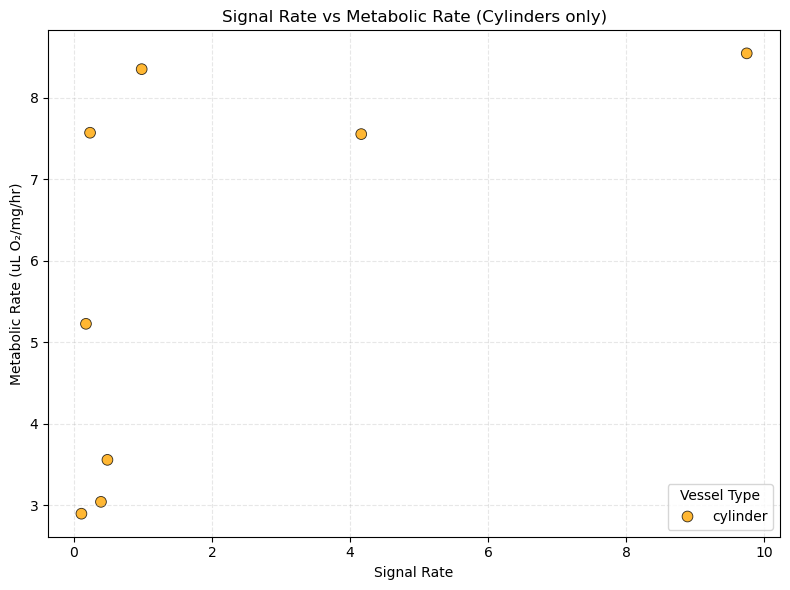

In [28]:
# Cylinders only, ignoring negative rates
import matplotlib.pyplot as plt
import seaborn as sns

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them
use_unfiltered = False

plt.figure(figsize=(8, 6))
if use_unfiltered:
    cyl_df = merged_df[merged_df['vessel'] == 'cylinder'].copy()
else:
    cyl_df = merged_df[(merged_df['vessel'] == 'cylinder') & (merged_df['filtered'] == True)].copy()

sns.scatterplot(
    data=cyl_df,
    x='signal_rate',
    y='RMR',
    hue='vessel',  # all 'cylinder'
    palette={'cylinder': 'orange'},
    s=60,
    edgecolor='black',
    alpha=0.8
)

plt.xlabel('Signal Rate')
plt.ylabel('Metabolic Rate (uL O₂/mg/hr)')
plt.title('Signal Rate vs Metabolic Rate (Cylinders only)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Vessel Type')
plt.tight_layout()
plt.show()

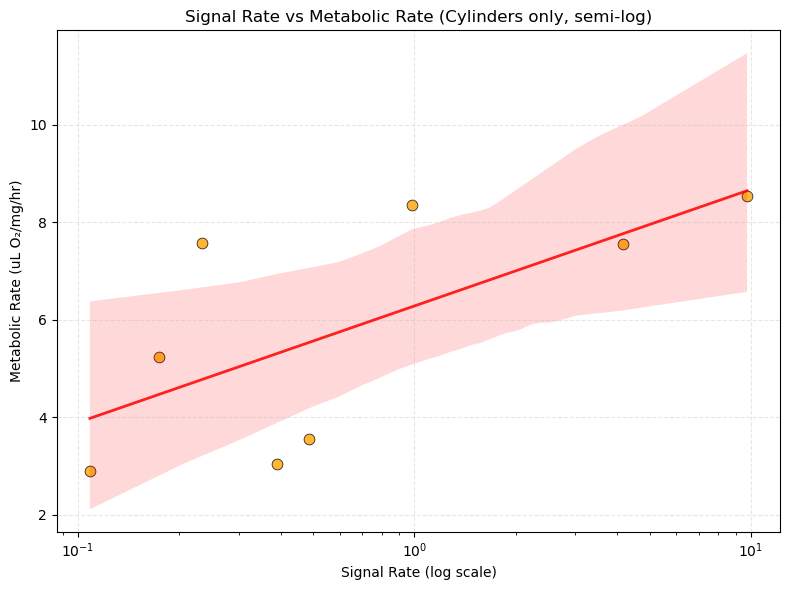

Slope: 2.3905
Intercept: 6.2853
R²: 0.4471
p-value: 6.9859e-02
Std err: 1.0853


In [29]:
# Cylinders only: semi-log x, ignore negatives, show regression stats (no legend)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them
use_unfiltered = False

if use_unfiltered:
    cyl_df = merged_df[
        (merged_df['vessel'] == 'cylinder') &
        (merged_df['signal_rate'] > 0)
    ].copy()
else:
    cyl_df = merged_df[
        (merged_df['vessel'] == 'cylinder') &
        (merged_df['filtered'] == True) &
        (merged_df['signal_rate'] > 0)
    ].copy()

if cyl_df.empty:
    print("No cylinder data available for plotting.")
else:
    # log10 transform for regression
    cyl_df['signal_rate_log10'] = np.log10(cyl_df['signal_rate'])

    # Linear regression on log10(signal_rate) vs RMR
    slope, intercept, r_value, p_value, stderr = stats.linregress(
        cyl_df['signal_rate_log10'], cyl_df['RMR']
    )
    r2 = r_value ** 2

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=cyl_df,
        x='signal_rate',
        y='RMR',
        color='orange',
        s=60,
        edgecolor='black',
        alpha=0.8,
        legend=False
    )
    # Regression line in data space (use regplot for convenience)
    sns.regplot(
        data=cyl_df,
        x='signal_rate',
        y='RMR',
        scatter=False,
        logx=True,
        line_kws={'color': 'red', 'alpha': 0.85, 'linewidth': 2}
    )

    plt.xscale('log')
    plt.xlabel('Signal Rate (log scale)')
    plt.ylabel('Metabolic Rate (uL O₂/mg/hr)')
    plt.title('Signal Rate vs Metabolic Rate (Cylinders only, semi-log)')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Slope: {slope:.4f}")
    print(f"Intercept: {intercept:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p_value:.4e}")
    print(f"Std err: {stderr:.4f}")

## From Niko's statistical analyses

## Supplemental cells and tools -- used while building the notebook

In [20]:
from pathlib import Path
import re

r_dir = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/adriana_final_r')

# Pattern to find ANY incorrect subset syntax (using regex)
incorrect_pattern = re.compile(r'trim_data<-subset\(Data,hours>=[\d.]+ &Data,hours<=[\d.]+\)')

# Process all .R files
for r_file in r_dir.glob('*.R'):
    with open(r_file, 'r') as f:
        lines = f.readlines()
    
    modified = False
    new_lines = []
    
    for i, line in enumerate(lines):
        if incorrect_pattern.search(line) and not line.strip().startswith('#'):
            # Found incorrect syntax that's not already commented out
            # Comment out the old line
            new_lines.append(f'#{line.rstrip()} #SYNTAX ERROR - this included all data!\n')
            
            # Extract the hour values to preserve them
            match = re.search(r'hours>=([\d.]+) &Data,hours<=([\d.]+)', line)
            if match:
                start_hour = match.group(1)
                end_hour = match.group(2)
                new_lines.append(f'trim_data<-subset(Data, hours>={start_hour} & hours<={end_hour}) #CORRECTED\n')
            else:
                # Fallback to default
                new_lines.append('trim_data<-subset(Data, hours>=1 & hours<=8) #CORRECTED\n')
            
            modified = True
            print(f"  Fixed line in {r_file.name}: {line.strip()}")
        else:
            new_lines.append(line)
    
    if modified:
        # Backup original
        backup_file = r_file.with_suffix('.R.bak')
        with open(backup_file, 'w') as f:
            f.writelines(lines)
        
        # Write corrected file
        with open(r_file, 'w') as f:
            f.writelines(new_lines)
        
        print(f"✓ Fixed: {r_file.name}\n")
    else:
        print(f"✓ No changes needed: {r_file.name}")

print("\nAll R scripts have been processed!")

✓ No changes needed: newpyro-trial7-dark.R
✓ No changes needed: newpyro-trial2.R
✓ No changes needed: box3-trial7-dark.R
✓ No changes needed: box2-trial2.R
✓ No changes needed: newpyro-trial5.R
✓ No changes needed: newpyro-trial1.R
✓ No changes needed: box3-trial5.R
✓ No changes needed: box2-trial5.R
✓ No changes needed: box2-trial1.R
✓ No changes needed: box3-trial1.R
✓ No changes needed: box3-trial6-dark.R
✓ No changes needed: newpyro-trial7-light.R
✓ No changes needed: newpyro-trial4.R
✓ No changes needed: newpyro-trial6-dark.R
✓ No changes needed: box3-trial7-light.R
✓ No changes needed: box3-trial6-light.R
✓ No changes needed: box2-trial4.R
✓ No changes needed: box3-trial4.R
✓ No changes needed: newpyro-trial6-light.R
✓ No changes needed: box3-trial4-light.R
✓ No changes needed: newpyro-trial3.R
✓ No changes needed: newpyro-trial5-light.R
✓ No changes needed: box2-trial4-light.R
✓ No changes needed: box2-trial3.R
✓ No changes needed: box3-trial3.R
✓ No changes needed: box3-trial5-

In [21]:
import re
from pathlib import Path

r_dir = Path("/Users/oakley/Documents/GitHub/signal_respirometry/data/adriana_final_r")

setwd_old = 'setwd("F:/Ostracod Respirometry")'
setwd_block = [
    "#File directory Adriana\n",
    '#setwd("F:/Ostracod Respirometry")\n',
    "\n",
    "#File directory Todd\n",
    'setwd("/Users/oakley/Documents/GitHub/signal_respirometry/data/adriana_final_r")\n',
]

plot_patterns = (
    re.compile(r'^\s*plot\('),
    re.compile(r'^\s*lot\('),  # catches the typo line
)

changed_files = []

for r_file in r_dir.glob("*.R"):
    with open(r_file, "r") as f:
        lines = f.readlines()

    needs_setwd = any(setwd_old in ln and not ln.lstrip().startswith("#") for ln in lines)
    already_block = any("File directory Todd" in ln for ln in lines)

    new_lines = []
    modified = False

    i = 0
    while i < len(lines):
        line = lines[i]

        # Replace setwd block once if needed
        if needs_setwd and (setwd_old in line) and not line.lstrip().startswith("#"):
            new_lines.extend(setwd_block)
            modified = True
            i += 1
            continue

        # Comment plot/lot lines if not already commented
        if not line.lstrip().startswith("#") and any(pat.search(line) for pat in plot_patterns):
            new_lines.append("#" + line.lstrip())  # comment while trimming leading spaces
            modified = True
            i += 1
            continue

        new_lines.append(line)
        i += 1

    # If already has the Todd block, leave as-is
    if already_block:
        needs_setwd = False  # don't treat as modified for setwd reason

    if modified:
        with open(r_file, "w") as f:
            f.writelines(new_lines)
        changed_files.append(r_file.name)

print("Updated files:" if changed_files else "No changes needed.")
for name in changed_files:
    print(f"  ✓ {name}")

No changes needed.


In [22]:
#This Tool extracts the masses from the R scripts and creates a summary table

import re
from pathlib import Path
import pandas as pd

base = Path("/Users/oakley/Documents/GitHub/signal_respirometry/data/adriana_final_r")
files = [
    "newpyro-trial6-light.R",
]

#All the files
#"newpyro-trial2.R","box3-trial7-dark.R","box2-trial2.R","newpyro-trial5.R",
#"newpyro-trial1.R","box3-trial5.R","box2-trial5.R","box2-trial1.R","box3-trial1.R","box3-trial6-dark.R",
#"newpyro-trial7-light.R","newpyro-trial4.R","newpyro-trial6-dark.R","box3-trial7-light.R","box3-trial6-light.R",
#"box2-trial4.R","box3-trial4.R","newpyro-trial6-light.R","box3-trial4-light.R","newpyro-trial3.R",
#"newpyro-trial5-light.R","box2-trial4-light.R","box2-trial3.R","box3-trial3.R","box3-trial5-light.R"

mass_re = re.compile(r"^Mass(\d+)\s*<-\s*([0-9.eE+-]+)")

records = []
for fname in files:
    path = base / fname
    if not path.exists():
        continue
    brick_raw, trial_part = path.stem.split("-", 1)
    box = "newbox" if brick_raw == "newpyro" else brick_raw  # map newpyro→newbox
    with path.open() as f:
        for line in f:
            m = mass_re.match(line.strip())
            if m:
                channel = f"Ch{int(m.group(1))}"
                mass = float(m.group(2))
                records.append({
                    "box": box,
                    "trial": trial_part,   # includes light/dark suffix if present
                    "channel": channel,
                    "mass_g": mass,
                    "file": str(path),
                })

df = pd.DataFrame(records).sort_values(["box","trial","channel"]).reset_index(drop=True)
display(df)
print(", ".join(df["mass_g"].astype(str)))

,box,trial,channel,mass_g,file
0,newbox,trial6-light,Ch2,0.000193,/Users/oakley/Documents/GitHub/signal_respirom...
1,newbox,trial6-light,Ch3,0.000241,/Users/oakley/Documents/GitHub/signal_respirom...
2,newbox,trial6-light,Ch4,0.000228,/Users/oakley/Documents/GitHub/signal_respirom...


0.000193, 0.0002411, 0.0002281


## Additional Analysis - Mass vs RMR/A Relationships

This section replicates the R analysis scripts for mass scaling relationships and mixed effects models.

In [35]:
# Load and prepare data for mass scaling analysis
# This replicates the R tidyverse data preparation

# Using the aggregated dataframe from earlier analysis
if 'agg_df' in locals() and not agg_df.empty:
    dat = agg_df.copy()
    
    # Calculate per-individual mass (using corrected if available)
    dat['mass_per_ind'] = dat.apply(
        lambda row: (row['corrected_mass_mg'] if pd.notna(row['corrected_mass_mg']) 
                     else row['total_mass_mg']) / (row['n'] if pd.notna(row['n']) and row['n'] is not None else 1),
        axis=1
    )
    
    # Convert mass from mg to ug for consistency with R script
    dat['mass_ug'] = dat['mass_per_ind'] * 1000
    
    # Add vessel categorization
    def categorize_vessel(n):
        if pd.isna(n) or n is None:
            n = 1
        if n == 1:
            return "Individual"
        elif n < 10:
            return "Vial"
        else:
            return "Column"
    
    dat['Vessel'] = dat['n'].apply(categorize_vessel)
    dat['Vessel'] = pd.Categorical(dat['Vessel'], categories=['Column', 'Vial', 'Individual'], ordered=True)
    
    # Identify paired measurements (individuals from trials 4-7 with day/night)
    dat['paired'] = ((dat['Vessel'] == 'Individual') & 
                     (dat['trial'].isin(['trial4', 'trial4.5', 'trial5', 'trial5.5', 
                                        'trial6', 'trial6.5', 'trial7', 'trial7.5'])))
    
    # Identify if trial started during day (trials 4, 5) or night (trials 6, 7)
    def day_first_flag(row):
        if not row['paired']:
            return None
        trial_base = row['trial'].replace('.5', '')
        return trial_base in ['trial4', 'trial5']
    
    dat['day_first'] = dat.apply(day_first_flag, axis=1)
    
    # Create night_measured flag (environment == 'night')
    dat['night_measured'] = dat['environment'] == 'night'
    
    # Create VesselxTime combined category
    def vessel_time_category(row):
        if row['Vessel'] == 'Individual' and row['paired']:
            if row['night_measured']:
                return 'Individual Night'
            else:
                return 'Individual Day'
        elif row['Vessel'] == 'Individual':
            return 'Individual Unpaired'
        else:
            return row['Vessel']
    
    dat['VesselxTime'] = dat.apply(vessel_time_category, axis=1)
    dat['VesselxTime'] = pd.Categorical(dat['VesselxTime'], 
                                        categories=['Column', 'Vial', 'Individual Unpaired', 
                                                   'Individual Night', 'Individual Day'], 
                                        ordered=True)
    
    # Create pair_id for paired observations
    dat['pair_id'] = dat.apply(
        lambda row: f"{row['trial']}_{row['channel']}" if row['paired'] else None, 
        axis=1
    )
    
    print(f"Data prepared: {len(dat)} observations")
    print(f"Vessel distribution:\n{dat['Vessel'].value_counts().sort_index()}")
    print(f"\nPaired observations: {dat['paired'].sum()}")
    
else:
    print("Error: agg_df not found. Run the aggregation cell first.")

Data prepared: 71 observations
Vessel distribution:
Vessel
Column        10
Vial           6
Individual    55
Name: count, dtype: int64

Paired observations: 46


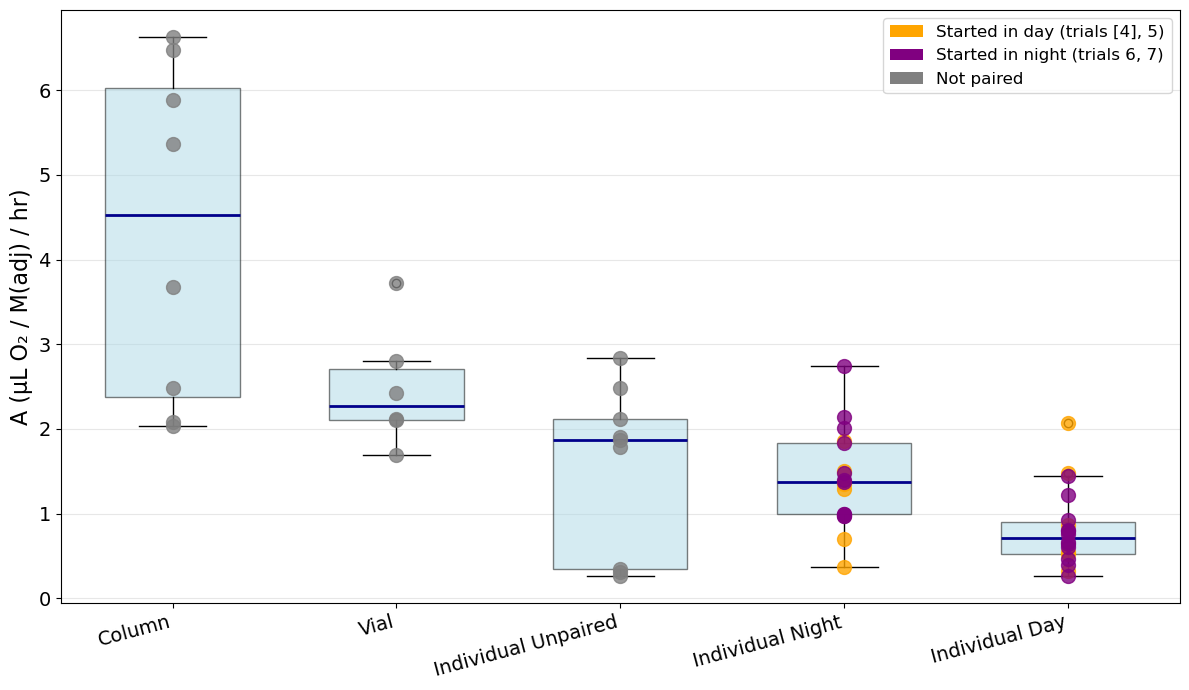

In [ ]:
# Boxplot with paired lines (replicating THO's plot)
# Shows A (metabolic rate) across different vessel types and measurement times

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them
use_unfiltered = False

# Apply filtering based on toggle
plot_dat = dat.copy() if use_unfiltered else dat[dat['filtered'] == True].copy()

fig, ax = plt.subplots(figsize=(12, 7))

# Prepare data for plotting
plot_data = plot_dat.dropna(subset=['A']).copy()
x_categories = ['Column', 'Vial', 'Individual Unpaired', 'Individual Night', 'Individual Day']

# Create boxplot
bp = ax.boxplot(
    [plot_data[plot_data['VesselxTime'] == cat]['A'].dropna() for cat in x_categories],
    positions=range(len(x_categories)),
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', alpha=0.5),
    medianprops=dict(color='darkblue', linewidth=2)
)

# Add paired lines
paired_data = plot_data[plot_data['paired'] == True].copy()
for pair_id in paired_data['pair_id'].unique():
    pair_subset = paired_data[paired_data['pair_id'] == pair_id]
    if len(pair_subset) == 2:
        night_row = pair_subset[pair_subset['night_measured'] == True]
        day_row = pair_subset[pair_subset['night_measured'] == False]
        
        if len(night_row) > 0 and len(day_row) > 0:
            x_night = x_categories.index('Individual Night')
            x_day = x_categories.index('Individual Day')
            y_night = night_row['A'].iloc[0]
            y_day = day_row['A'].iloc[0]
            
            # Color by day_first
            day_first_val = night_row['day_first'].iloc[0]
            color = 'orange' if day_first_val else 'purple'
            
            ax.plot([x_night, x_day], [y_night, y_day], 
                   color=color, alpha=0.6, linewidth=1.5)

# Add individual points
for i, cat in enumerate(x_categories):
    cat_data = plot_data[plot_data['VesselxTime'] == cat]
    
    # Color by day_first for individuals
    for _, row in cat_data.iterrows():
        if pd.notna(row['day_first']):
            color = 'orange' if row['day_first'] else 'purple'
        else:
            color = 'gray'
        ax.scatter(i, row['A'], s=100, color=color, alpha=0.8, zorder=3)

ax.set_xticks(range(len(x_categories)))
ax.set_xticklabels(x_categories, fontsize=14, rotation=15, ha='right')
ax.set_ylabel('A (µL O₂ / M(adj) / hr)', fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.grid(True, alpha=0.3, axis='y')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='orange', label='Started in day (trials 4, 5)'),
    Patch(facecolor='purple', label='Started in night (trials 6, 7)'),
    Patch(facecolor='gray', label='Not paired')
]
ax.legend(handles=legend_elements, fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

### Linear Mixed Effects Model

Analyze variation in A (mass-adjusted metabolic rate) based on:
- **night_measured**: Whether measurement was taken at night (TRUE) or day (FALSE)
- **day_first**: Whether the trial started during day (TRUE) or night (FALSE)
- **pair_id**: Random effect for paired measurements

This replicates the R `lmer` analysis.

In [41]:
# Linear Mixed Effects Model - All Individual Data
# Requires: pip install statsmodels

import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them
use_unfiltered = False

# Apply filtering based on toggle
model_dat = dat.copy() if use_unfiltered else dat[dat['filtered'] == True].copy()

# Filter for individual measurements only
ind_data = model_dat[model_dat['Vessel'] == 'Individual'].copy()

# Convert to appropriate types for modeling
ind_data['night_measured'] = ind_data['night_measured'].astype('category')
ind_data['day_first'] = ind_data['day_first'].astype('category')
ind_data['pair_id'] = ind_data['pair_id'].astype('category')

# Remove rows with missing values in key columns
model_data = ind_data.dropna(subset=['A', 'night_measured', 'day_first', 'pair_id'])

if len(model_data) > 0:
    print(f"Fitting mixed effects model with {len(model_data)} observations")
    print(f"Number of pairs: {model_data['pair_id'].nunique()}")
    
    # Fit the model: A ~ night_measured * day_first + (1 | pair_id)
    # This matches: lmer(M_adj ~ night_measured * day_first + (1| pair_id), data = ind_data_only)
    
    model = MixedLM.from_formula(
        'A ~ night_measured * day_first',
        data=model_data,
        groups=model_data['pair_id']
    )
    
    result = model.fit(reml=False)  # ML estimation (REML=FALSE in R)
    
    print("\n" + "="*70)
    print("Mixed Effects Model Summary")
    print("="*70)
    print(result.summary())
    
    # Store result for later use
    mixed_model_result = result
    
else:
    print("Insufficient data for mixed effects model")

Fitting mixed effects model with 35 observations
Number of pairs: 18

Mixed Effects Model Summary
                       Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          A       
No. Observations:            35               Method:                      ML      
No. Groups:                  18               Scale:                       0.2275  
Min. group size:             1                Log-Likelihood:              -26.6111
Max. group size:             2                Converged:                   Yes     
Mean group size:             1.9                                                   
-----------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                 0.748    0.162  4.618 0.000  0.431  1.066
n

/opt/homebrew/Caskroom/miniforge/base/envs/respirometry/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/Caskroom/miniforge/base/envs/respirometry/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/respirometry/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [42]:
# Estimated Marginal Means (EMMs) with 95% CI
# This replicates the emmeans functionality from R

if 'mixed_model_result' in locals():
    # Calculate predicted values for each combination of night_measured and day_first
    # Create prediction grid
    pred_grid = pd.DataFrame({
        'night_measured': [True, True, False, False],
        'day_first': [True, False, True, False]
    })
    pred_grid['night_measured'] = pred_grid['night_measured'].astype('category')
    pred_grid['day_first'] = pred_grid['day_first'].astype('category')
    
    # Get predictions (fixed effects only, no random effects)
    predictions = mixed_model_result.predict(exog=pred_grid)
    
    # Calculate confidence intervals
    # Get the design matrix
    from statsmodels.tools.sm_exceptions import PerfectSeparationError
    
    try:
        # Manual calculation of SEs using the design matrix
        import patsy
        formula = 'night_measured * day_first'
        X = patsy.dmatrix(formula, pred_grid, return_type='dataframe')
        
        # Standard errors of predictions
        cov = mixed_model_result.cov_params()
        se = np.sqrt(np.diag(X @ cov @ X.T))
        
        # 95% CI (using z-score for large samples)
        z_crit = 1.96
        ci_lower = predictions - z_crit * se
        ci_upper = predictions + z_crit * se
        
        # Create results dataframe
        emm_results = pd.DataFrame({
            'night_measured': pred_grid['night_measured'],
            'day_first': pred_grid['day_first'],
            'emmean': predictions,
            'lower_CL': ci_lower,
            'upper_CL': ci_upper,
            'SE': se
        })
        
        # Format for display
        emm_results['night_measured_label'] = emm_results['night_measured'].map({True: 'Night', False: 'Day'})
        
        print("\n" + "="*70)
        print("Estimated Marginal Means (EMMs) with 95% CI")
        print("="*70)
        display(emm_results[['night_measured_label', 'day_first', 'emmean', 'SE', 'lower_CL', 'upper_CL']])
        
    except Exception as e:
        print(f"Error calculating EMMs: {e}")
        print("Using simple predictions instead")
        emm_results = pd.DataFrame({
            'night_measured': pred_grid['night_measured'],
            'day_first': pred_grid['day_first'],
            'emmean': predictions
        })
        emm_results['night_measured_label'] = emm_results['night_measured'].map({True: 'Night', False: 'Day'})
        display(emm_results)
        
else:
    print("Run the mixed model cell first")

Error calculating EMMs: matrices are not aligned
Using simple predictions instead


,night_measured,day_first,emmean,night_measured_label
0,True,True,1.178045,Night
1,True,False,1.527546,Night
2,False,True,0.968145,Day
3,False,False,0.748365,Day


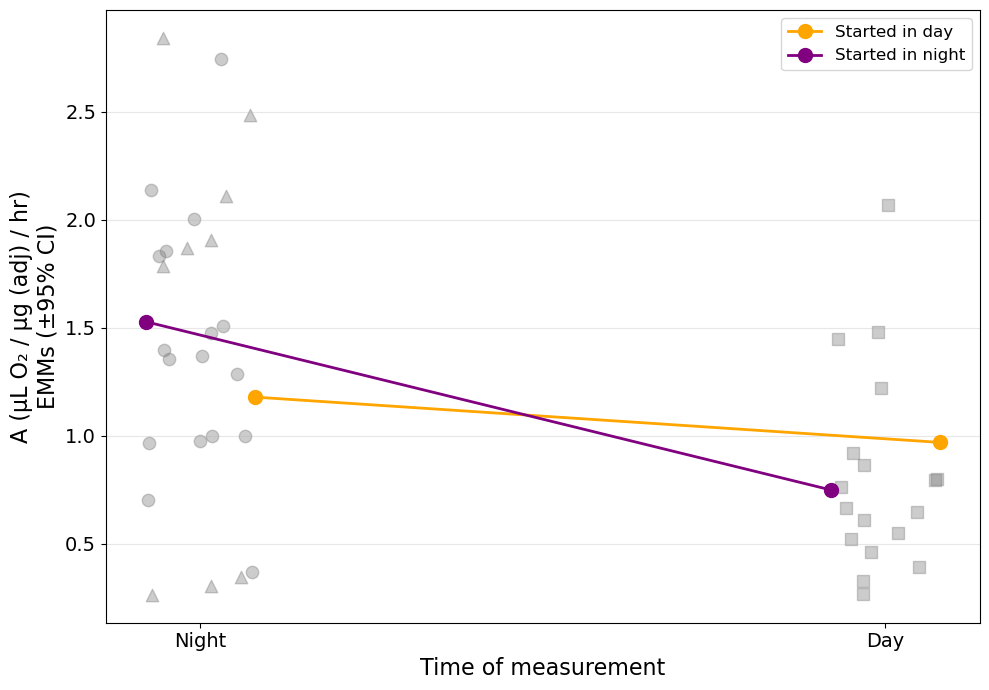

In [43]:
# Plot EMMs with raw data
# Replicates the final emmeans plot from R script

import numpy as np
import matplotlib.pyplot as plt

if 'emm_results' in locals() and 'ind_data' in locals():
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Plot raw data points (jittered)
    np.random.seed(42)
    plot_ind_data = ind_data.dropna(subset=['A', 'night_measured', 'VesselxTime']).copy()
    
    for _, row in plot_ind_data.iterrows():
        x_pos = 0 if row['night_measured'] else 1
        x_jitter = x_pos + np.random.uniform(-0.08, 0.08)
        
        # Shape by vessel type
        if row['VesselxTime'] == 'Individual Night':
            marker = 'o'
        elif row['VesselxTime'] == 'Individual Day':
            marker = 's'
        else:
            marker = '^'
        
        ax.scatter(x_jitter, row['A'], marker=marker, s=80, alpha=0.4, color='gray')
    
    # Convert categorical columns to bool/object for easier comparison
    emm_plot = emm_results.copy()
    emm_plot['night_measured'] = emm_plot['night_measured'].astype(bool)
    emm_plot['day_first'] = emm_plot['day_first'].astype(bool)
    
    # Plot EMMs with error bars
    if 'lower_CL' in emm_plot.columns:
        for day_first_val in [True, False]:
            subset = emm_plot[emm_plot['day_first'] == day_first_val]
            color = 'orange' if day_first_val else 'purple'
            label = 'Started in day' if day_first_val else 'Started in night'
            
            x_positions = [0 if night else 1 for night in subset['night_measured'].values]
            # Dodge positions
            offset = 0.08 if day_first_val else -0.08
            x_positions = [x + offset for x in x_positions]
            
            # Plot means
            ax.plot(x_positions, subset['emmean'].values, 'o-', color=color, 
                   markersize=10, linewidth=2, label=label, zorder=3)
            
            # Plot error bars
            ax.errorbar(x_positions, subset['emmean'].values,
                       yerr=[subset['emmean'].values - subset['lower_CL'].values, 
                             subset['upper_CL'].values - subset['emmean'].values],
                       fmt='none', color=color, capsize=5, capthick=2, 
                       linewidth=2, alpha=0.8, zorder=3)
    else:
        # Simplified version without CIs
        for day_first_val in [True, False]:
            subset = emm_plot[emm_plot['day_first'] == day_first_val]
            color = 'orange' if day_first_val else 'purple'
            label = 'Started in day' if day_first_val else 'Started in night'
            
            x_positions = [0 if night else 1 for night in subset['night_measured'].values]
            offset = 0.08 if day_first_val else -0.08
            x_positions = [x + offset for x in x_positions]
            
            ax.plot(x_positions, subset['emmean'].values, 'o-', color=color, 
                   markersize=10, linewidth=2, label=label, zorder=3)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Night', 'Day'], fontsize=16)
    ax.set_xlabel('Time of measurement', fontsize=16)
    ax.set_ylabel('A (µL O₂ / µg (adj) / hr)\nEMMs (±95% CI)', fontsize=16)
    ax.tick_params(labelsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=12, loc='best')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Run the EMM calculation cell first")

In [48]:
# Linear Mixed Effects Model - PAIRED DATA ONLY
# Replicates the second model analysis with only paired observations

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them
use_unfiltered = False

# Apply filtering based on toggle
paired_dat = dat.copy() if use_unfiltered else dat[dat['filtered'] == True].copy()

# Filter for paired individual measurements only
paired_ind_data = paired_dat[(paired_dat['Vessel'] == 'Individual') & (paired_dat['paired'] == True)].copy()

# Convert to appropriate types for modeling
paired_ind_data['night_measured'] = paired_ind_data['night_measured'].astype('category')
paired_ind_data['day_first'] = paired_ind_data['day_first'].astype('category')
paired_ind_data['pair_id'] = paired_ind_data['pair_id'].astype('category')

# Remove rows with missing values
paired_model_data = paired_ind_data.dropna(subset=['A', 'night_measured', 'day_first', 'pair_id'])

if len(paired_model_data) > 0:
    print(f"Fitting mixed effects model (PAIRED ONLY) with {len(paired_model_data)} observations")
    print(f"Number of pairs: {paired_model_data['pair_id'].nunique()}")
    
    # Fit the model
    paired_model = MixedLM.from_formula(
        'A ~ night_measured * day_first',
        data=paired_model_data,
        groups=paired_model_data['pair_id']
    )
    
    paired_result = paired_model.fit(reml=False)  # ML estimation (REML=FALSE in R)
    
    print("\n" + "="*70)
    print("Mixed Effects Model Summary (PAIRED DATA ONLY)")
    print("="*70)
    print(paired_result.summary())
    
    # Test interaction term significance
    # Compare full model to model without interaction
    reduced_model = MixedLM.from_formula(
        'A ~ night_measured + day_first',
        data=paired_model_data,
        groups=paired_model_data['pair_id']
    )
    reduced_result = reduced_model.fit(reml=False)
    
    # Likelihood ratio test
    lr_stat = 2 * (paired_result.llf - reduced_result.llf)
    from scipy.stats import chi2
    p_value = 1 - chi2.cdf(lr_stat, df=1)  # df=1 for one parameter difference
    
    print("\n" + "="*70)
    print("Likelihood Ratio Test for Interaction Term")
    print("="*70)
    print(f"LR statistic: {lr_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Conclusion: Interaction is {'significant' if p_value < 0.05 else 'not significant'} at α=0.05")
else:
    print("Insufficient paired data for mixed effects model")

Fitting mixed effects model (PAIRED ONLY) with 35 observations
Number of pairs: 18

Mixed Effects Model Summary (PAIRED DATA ONLY)
                       Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          A       
No. Observations:            35               Method:                      ML      
No. Groups:                  18               Scale:                       0.2275  
Min. group size:             1                Log-Likelihood:              -26.6111
Max. group size:             2                Converged:                   Yes     
Mean group size:             1.9                                                   
-----------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                 0.748    0

/opt/homebrew/Caskroom/miniforge/base/envs/respirometry/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/Caskroom/miniforge/base/envs/respirometry/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/respirometry/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/respirometry/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o